# Oil Price Prediction with LSTM

A professional notebook version of the project for GitHub.

## 1. Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

file_path = "/content/Crude_Oil_Data.csv"
df = pd.read_csv(file_path)
df.head()

,Date,Adj_Close,Close,High,Low,Open,Volume
0,2000-08-23 00:00:00+00:00,32.049999,32.049999,32.799999,31.950001,31.950001,79385
1,2000-08-24 00:00:00+00:00,31.629999,31.629999,32.240002,31.400000,31.900000,72978
2,2000-08-25 00:00:00+00:00,32.049999,32.049999,32.099998,31.320000,31.700001,44601
3,2000-08-28 00:00:00+00:00,32.869999,32.869999,32.919998,31.860001,32.040001,46770
4,2000-08-29 00:00:00+00:00,32.720001,32.720001,33.029999,32.560001,32.820000,49131


## 2. Data Preparation

In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(df.isnull().sum())
df.head()

Date         0
Adj_Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


,Date,Adj_Close,Close,High,Low,Open,Volume
0,2000-08-23 00:00:00+00:00,32.049999,32.049999,32.799999,31.950001,31.950001,79385
1,2000-08-24 00:00:00+00:00,31.629999,31.629999,32.240002,31.400000,31.900000,72978
2,2000-08-25 00:00:00+00:00,32.049999,32.049999,32.099998,31.320000,31.700001,44601
3,2000-08-28 00:00:00+00:00,32.869999,32.869999,32.919998,31.860001,32.040001,46770
4,2000-08-29 00:00:00+00:00,32.720001,32.720001,33.029999,32.560001,32.820000,49131


## 3. Exploratory Data Analysis

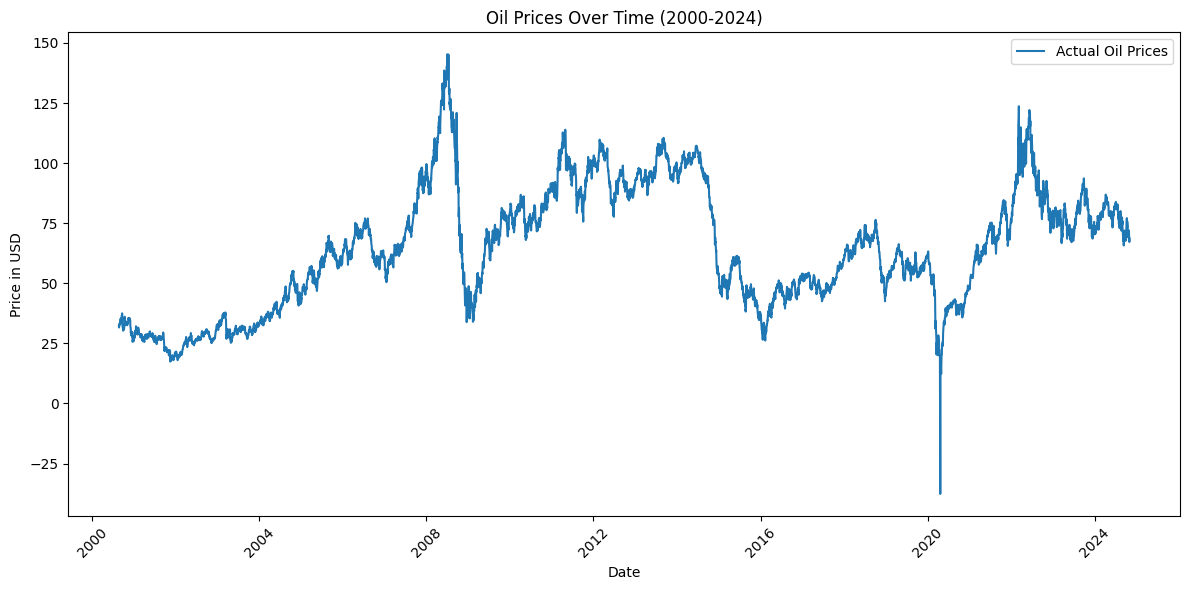

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Actual Oil Prices')
plt.title('Oil Prices Over Time (2000-2024)')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

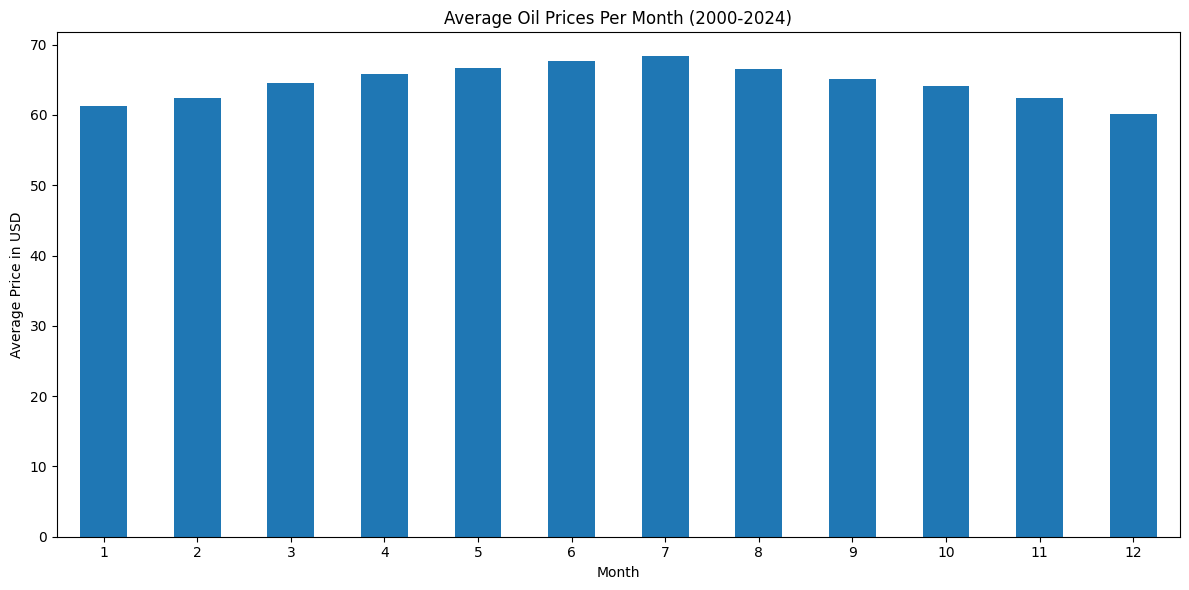

In [4]:
df['Month'] = df['Date'].dt.month
monthly_avg_prices = df.groupby('Month')['Close'].mean()

plt.figure(figsize=(12, 6))
monthly_avg_prices.plot(kind='bar')
plt.title('Average Oil Prices Per Month (2000-2024)')
plt.xlabel('Month')
plt.ylabel('Average Price in USD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

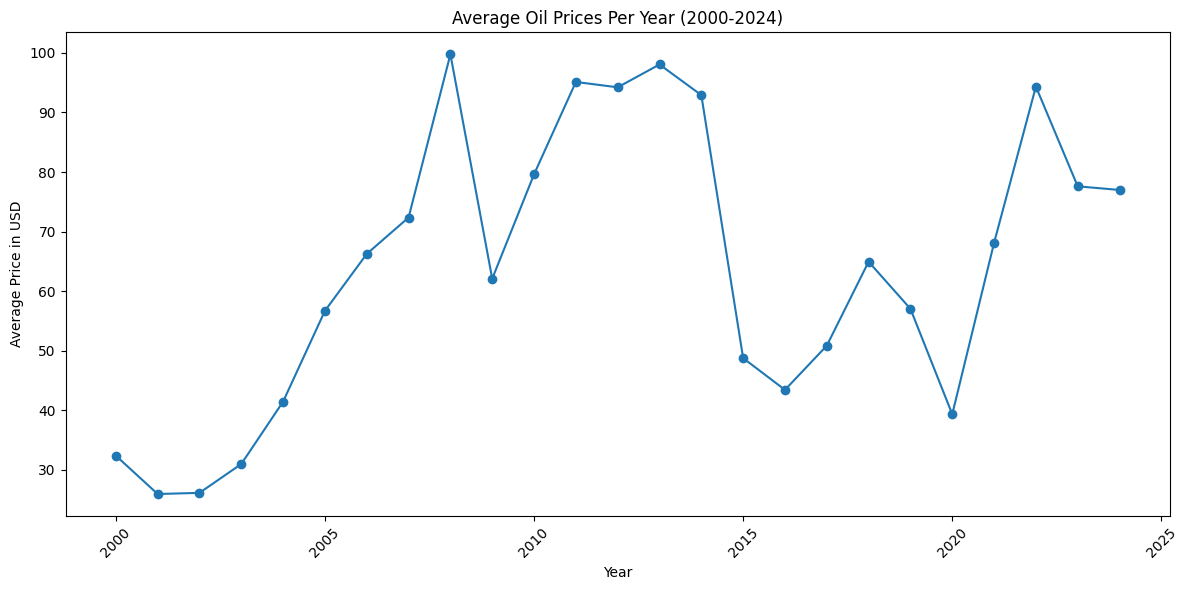

In [5]:
df['Year'] = df['Date'].dt.year
annual_avg_prices = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(12, 6))
annual_avg_prices.plot(kind='line', marker='o')
plt.title('Average Oil Prices Per Year (2000-2024)')
plt.xlabel('Year')
plt.ylabel('Average Price in USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

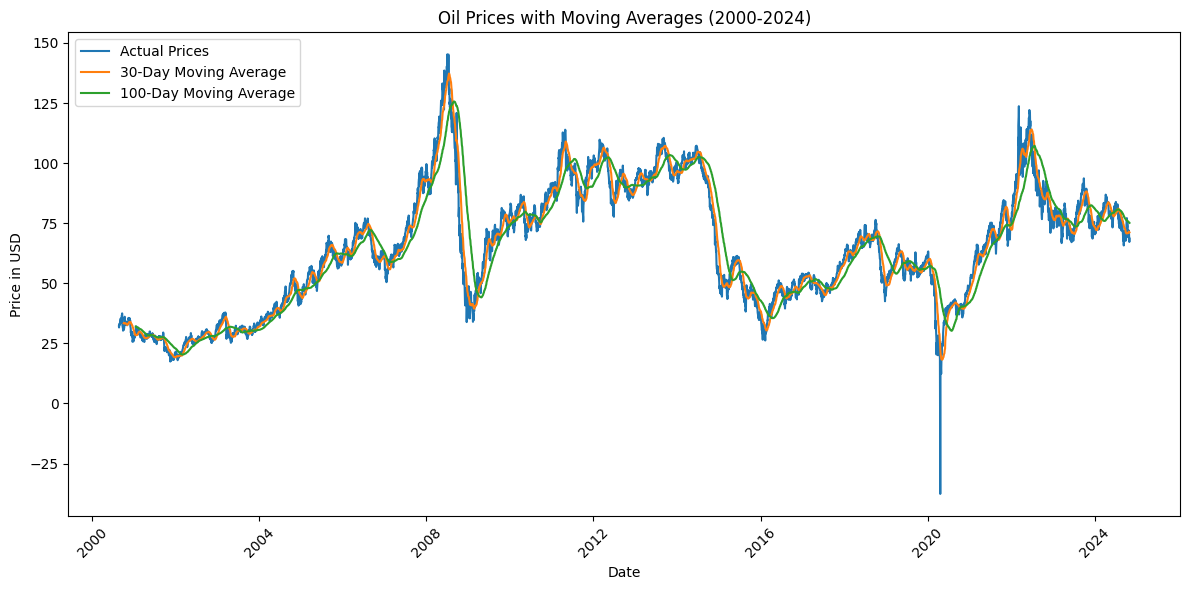

In [6]:
df['MA30'] = df['Close'].rolling(window=30).mean()
df['MA100'] = df['Close'].rolling(window=100).mean()

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Actual Prices')
plt.plot(df['Date'], df['MA30'], label='30-Day Moving Average')
plt.plot(df['Date'], df['MA100'], label='100-Day Moving Average')
plt.title('Oil Prices with Moving Averages (2000-2024)')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

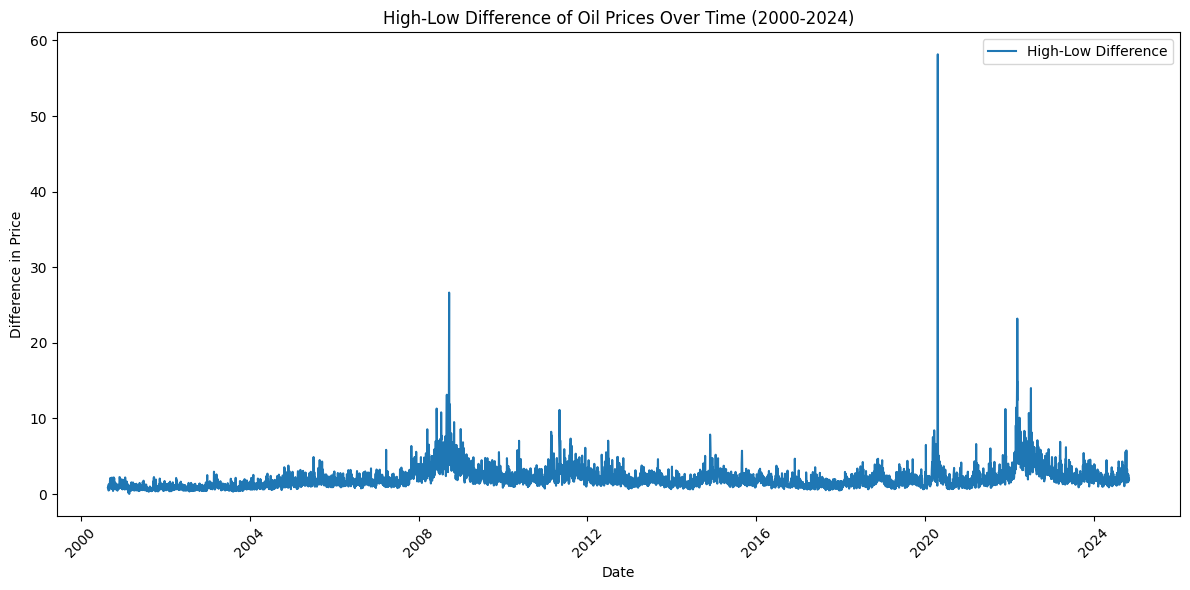

In [7]:
df['High-Low Difference'] = df['High'] - df['Low']

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['High-Low Difference'], label='High-Low Difference')
plt.title('High-Low Difference of Oil Prices Over Time (2000-2024)')
plt.xlabel('Date')
plt.ylabel('Difference in Price')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Data Scaling and Sequence Creation

In [8]:
model_df = df[['Close']].copy()

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(model_df)

def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

X_train, y_train = create_dataset(train_data, 60)
X_test, y_test = create_dataset(test_data, 60)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

X_train.shape, X_test.shape

((4798, 60, 1), (1155, 60, 1))

## 5. Model Architecture

In [9]:
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Training

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - loss: 0.0413 - val_loss: 5.8236e-04
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0029 - val_loss: 8.3933e-04
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 0.0025 - val_loss: 5.6044e-04
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - loss: 0.0022 - val_loss: 6.0181e-04
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - loss: 0.0022 - val_loss: 6.0726e-04
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.0020 - val_loss: 5.4102e-04
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 0.0019 - val_loss: 5.1941e-04
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - loss: 0.0018 - val_loss: 6.1036e-04
Epoch 9/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 0.0018 - val_loss: 5.2222e-04
Epoch 10/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 0.0015 - val_loss: 5.5089e-04
Epoch 11/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 0.0014 - val_loss: 4.96

## 7. Prediction and Evaluation

In [11]:
y_pred = model.predict(X_test)

y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

print('MSE:', mse)
print('RMSE:', rmse)
print('R²:', r2)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
MSE: 13.298068672300886
RMSE: 3.6466517070184925
R²: 0.9667991609120609


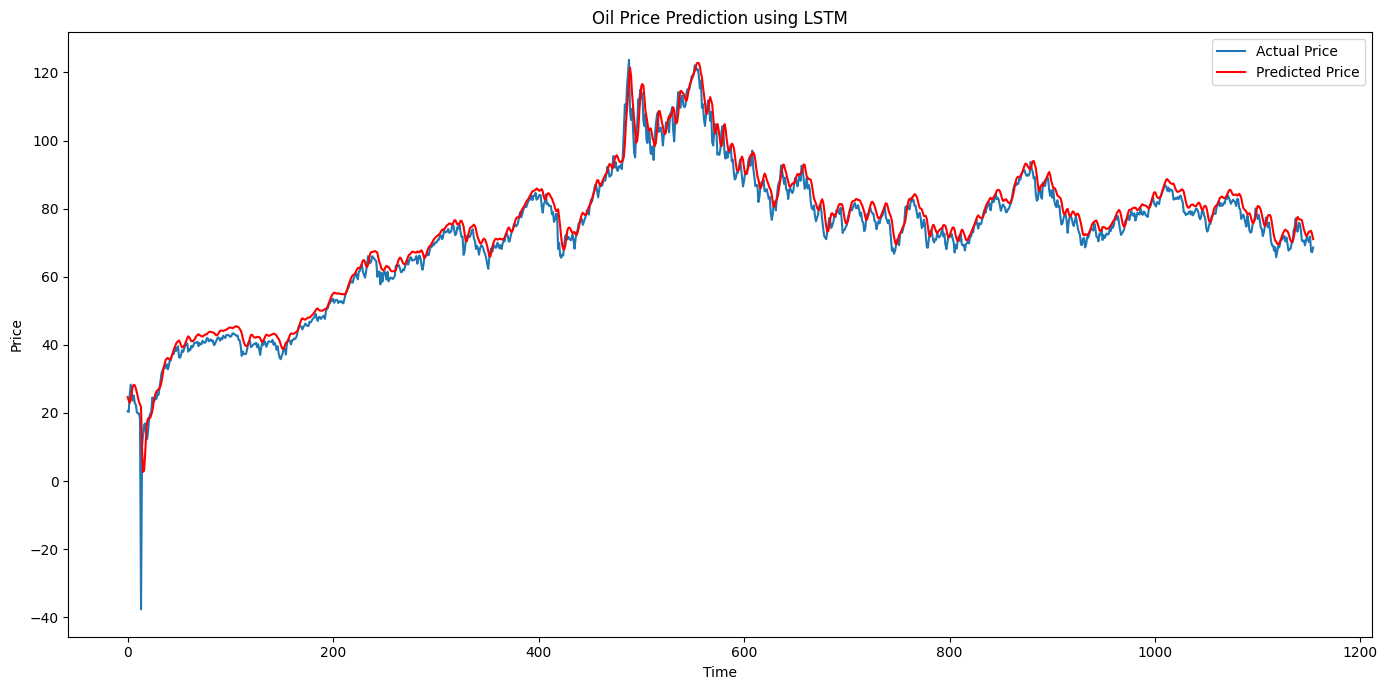

In [13]:
plt.figure(figsize=(14, 7))
plt.plot(y_test_rescaled, label='Actual Price')
plt.plot(y_pred_rescaled, label='Predicted Price' , color = "red")
plt.title('Oil Price Prediction using LSTM')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusion

This notebook demonstrates a clean end-to-end workflow for univariate oil price forecasting using LSTM.  
For stronger performance in future versions, the project can be extended with external economic, political, or sentiment-based features.


In [14]:
# save model
model.save("oil_lstm_model.h5")